#                     Problem statement (Term Deposit Sale) 

Goal 

Using the data collected from existing customers, build a model that will help the marketing team identify potential customers who are relatively more likely to subscribe term deposit and thus increase their hit ratio.


In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Reading the dataset


In [75]:
df=pd.read_csv('1602952227_bank-full.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Deliverable – 1 (Exploratory data quality report reflecting the following) 
1. Univariate analysis

a. Univariate analysis – data types and description of the independent attributes which should include (name, meaning, range of values observed, central values (mean and median), standard deviation and quartiles, analysis of the body of distributions / tails, missing values, outliers.

b. Strategies to address the different data challenges such as data pollution, outlier’s treatment and missing values treatment.

c. Please provide comments in jupyter notebook regarding the steps you take and insights drawn from the plots.


In [76]:
df.shape

(45211, 17)

In [77]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [79]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


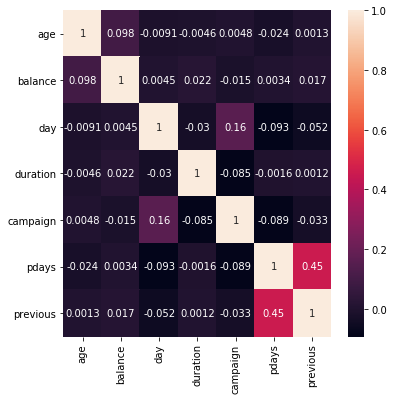

In [80]:
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(),annot=True)

In [81]:
Null_value=df.isnull().sum()
Null_value

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
Target       0
dtype: int64

# There is no null values present in the dataset

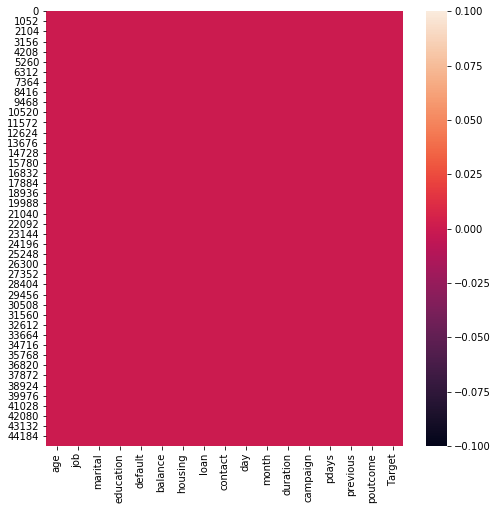

In [82]:
#we can also use plot the data to find which column have more missing values

#visualizing the pattern of missing value occurance

plt.figure(figsize=(8,8))
sns.heatmap(df.isnull())

In [83]:
df.age.unique()

array([58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 57, 51, 45, 60, 56, 32,
       25, 40, 39, 52, 46, 36, 49, 59, 37, 50, 54, 55, 48, 24, 38, 31, 30,
       27, 34, 23, 26, 61, 22, 21, 20, 66, 62, 83, 75, 67, 70, 65, 68, 64,
       69, 72, 71, 19, 76, 85, 63, 90, 82, 73, 74, 78, 80, 94, 79, 77, 86,
       95, 81, 18, 89, 84, 87, 92, 93, 88], dtype=int64)

# Boxplot 

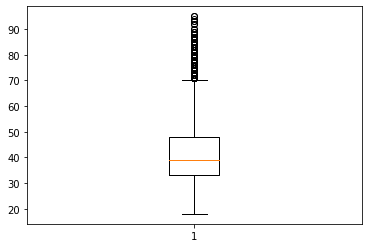

In [84]:
# Creating plot 
plt.boxplot(df.age) 
  
# show plot 
plt.show() 

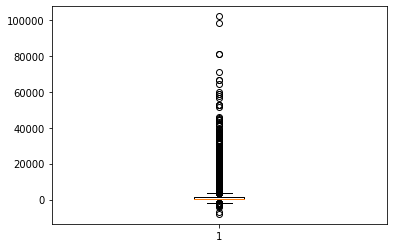

In [85]:
# Creating plot 
plt.boxplot(df.balance) 
  
# show plot 
plt.show() 

In [86]:
df.balance.unique()

array([ 2143,    29,     2, ...,  8205, 14204, 16353], dtype=int64)

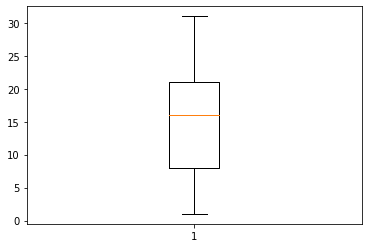

In [87]:
# Creating plot 
plt.boxplot(df.day) 
  
# show plot 
plt.show() 

# Countplot of columns

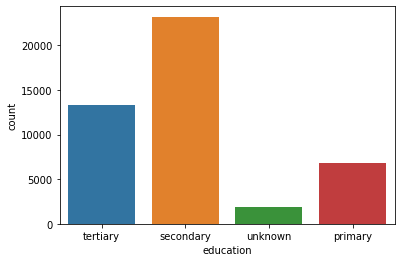

In [88]:
sns.countplot(x=df.education)
plt.show()

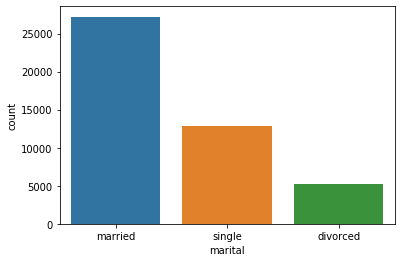

In [89]:
sns.countplot(x=df.marital)
plt.show()

<function matplotlib.pyplot.show(*args, **kw)>

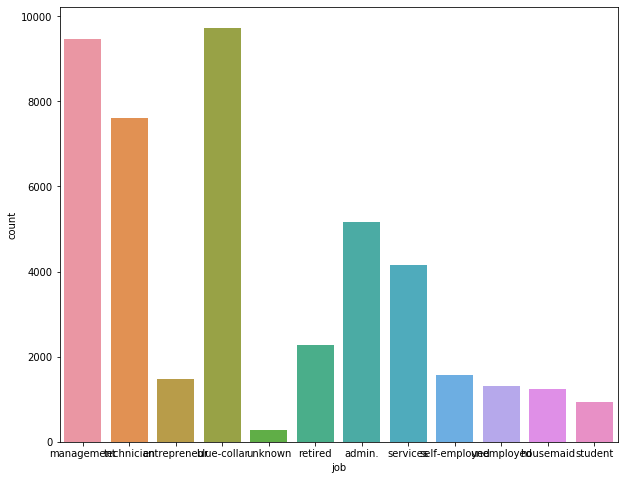

In [90]:
plt.figure(figsize=(10,8))
sns.countplot(x=df.job)
plt.show

<function matplotlib.pyplot.show(*args, **kw)>

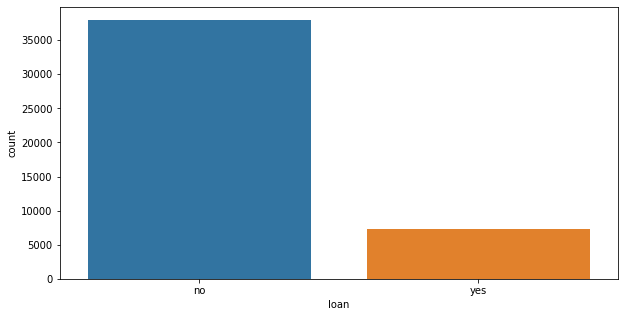

In [91]:
plt.figure(figsize=(10,5))
sns.countplot(x=df.loan)
plt.show

<function matplotlib.pyplot.show(*args, **kw)>

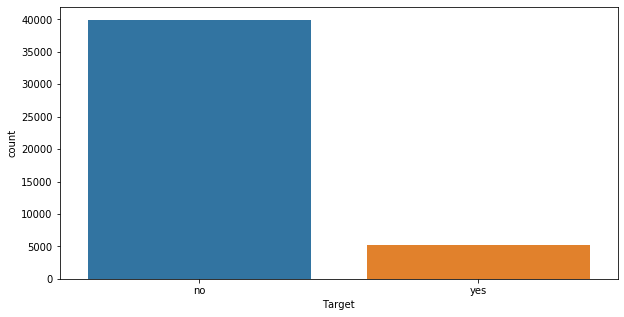

In [92]:
plt.figure(figsize=(10,5))
sns.countplot(x=df.Target)
plt.show

# Distplot

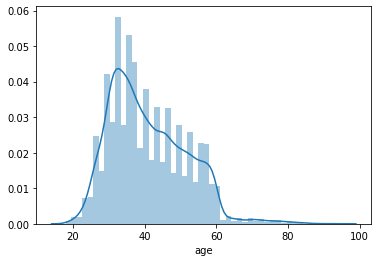

In [93]:
sns.distplot(df.age)
plt.show()

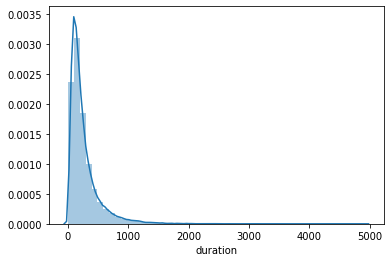

In [94]:
sns.distplot(df.duration)
plt.show()

In [95]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


# 2. Multivariate analysis 

a. Bi-variate analysis between the predictor variables and target column. Comment on your findings in terms of their relationship and degree of relation if any. Visualize the analysis using boxplots and pair plots, histograms or density curves. Select the most appropriate attributes.

b. Please provide comments in jupyter notebook regarding the steps you take and insights drawn from the plots


# Analysis of different predictor variables with the target column

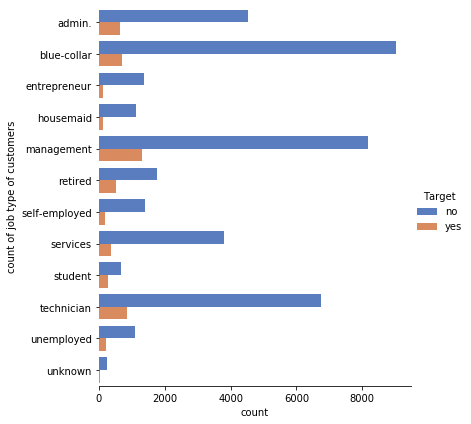

In [96]:
b=pd.DataFrame(df.groupby(['job','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='job', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of job type of customers")

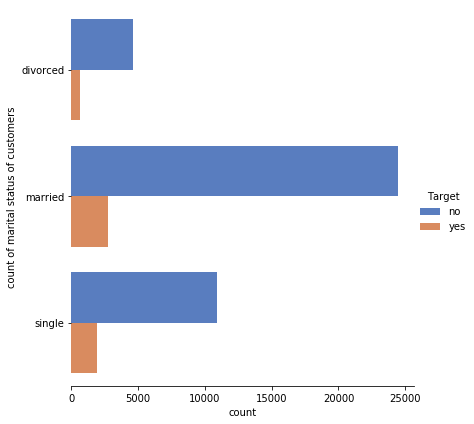

In [97]:
b=pd.DataFrame(df.groupby(['marital','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='marital', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of marital status of customers")

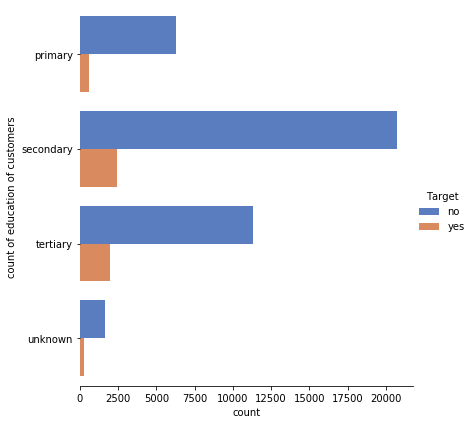

In [98]:
b=pd.DataFrame(df.groupby(['education','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='education', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of education of customers")

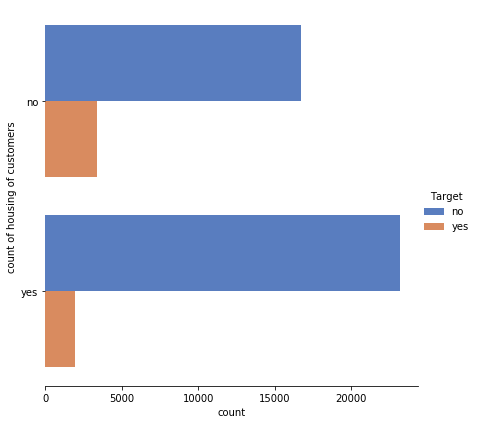

In [99]:
b=pd.DataFrame(df.groupby(['housing','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='housing', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of housing of customers")

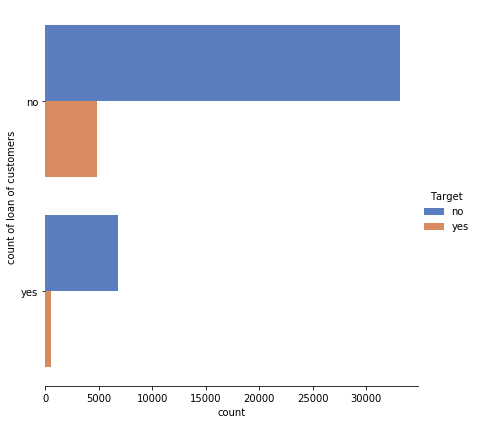

In [100]:
b=pd.DataFrame(df.groupby(['loan','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='loan', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of loan of customers")

In [101]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


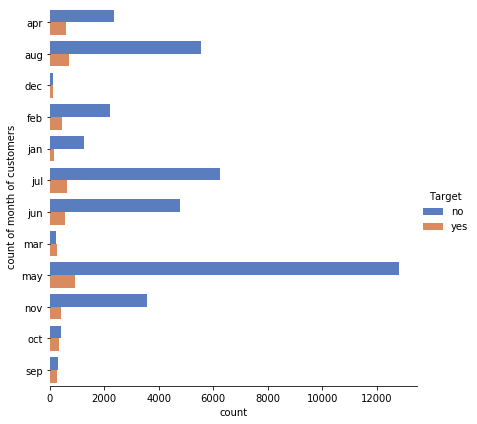

In [102]:
b=pd.DataFrame(df.groupby(['month','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='month', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of month of customers")

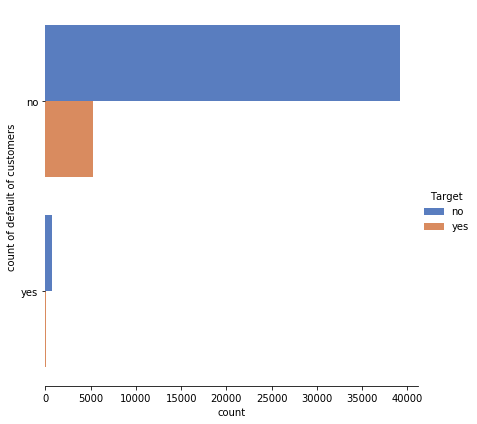

In [103]:
b=pd.DataFrame(df.groupby(['default','Target'])['Target'].count())
b.columns=['count']
b=b.reset_index()
g =sns.catplot(y='default', x='count', hue='Target', data=b,
                height=6, kind="bar", palette="muted")
g.despine(left=True)
g.set_ylabels("count of default of customers")

# Deliverable – 2 (Prepare the data for analytics) 

1. Ensure the attribute types are correct. If not, take appropriate actions. 

2. Get the data model ready. 

3. Transform the data i.e. scale / normalize if required 

4. Create the training set and test set in ratio of 70:30 


In [105]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# labelEncoder for converting categorical columns into numerical columns

In [109]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['job']=le.fit_transform(df['job'])
df['marital']=le.fit_transform(df['marital'])
df['education']=le.fit_transform(df['education'])
df['default']=le.fit_transform(df['default'])
df['housing']=le.fit_transform(df['housing'])
df['loan']=le.fit_transform(df['loan'])
df['contact']=le.fit_transform(df['contact'])
df['month']=le.fit_transform(df['month'])
df['poutcome']=le.fit_transform(df['poutcome'])
df['Target']=le.fit_transform(df['Target'])

In [110]:
df.shape

(45211, 17)

In [111]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


# splitting dataset into independentS(i.e X) and target(ie, Y)

In [113]:
X=df.drop('Target',axis=1)
Y=df['Target']

In [114]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=0)

# Deliverable – 3 (create the ensemble model) 

1. First create models using Logistic Regression and Decision Tree algorithm. Note the model performance by using different matrices. Use confusion matrix to evaluate class level metrics i.e. Precision/Recall. Also reflect the accuracy and F1 score of the model. 


# Logistic Regression


In [115]:
from sklearn.linear_model import LogisticRegression

C:\Users\saurav\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LRR Score= 88.47727524051753


confusion Matrix is:
[[7835  145]
 [ 897  166]]


Area under the curve: 0.7923274790928403




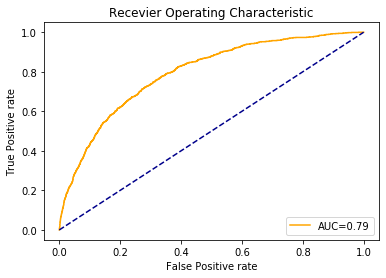

In [116]:
lr=LogisticRegression()
lr.fit(X_train,Y_train)
Y_predict=lr.predict(X_test)
cm=confusion_matrix(Y_test,Y_predict)
print('LRR Score=',lr.score(X_test,Y_test)*100)
print('\n')
print('confusion Matrix is:',cm,sep='\n')
print('\n')
from sklearn import metrics
probs=lr.predict_proba(X_test)
prob_positive =probs[:,1]
fpr,tpr,threshold=metrics.roc_curve(Y_test,prob_positive)
roc_auc=metrics.auc(fpr,tpr)
print('Area under the curve:',roc_auc)
print('\n')
plt.title('Recevier Operating Characteristic')
plt.plot(fpr,tpr,'orange',label='AUC=%0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.ylabel('True Positive rate')
plt.xlabel('False Positive rate')
plt.show()

# DecisionTreeClassifier


In [117]:
from sklearn.tree import DecisionTreeClassifier

DT Score= 86.78535884109255


confusion Matrix is:
[[7353  627]
 [ 568  495]]


Area under the curve: 0.6935458943690365




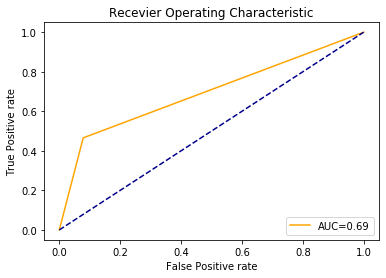

In [118]:
DT=DecisionTreeClassifier()
DT.fit(X_train,Y_train)
Y_predict=DT.predict(X_test)
cm=confusion_matrix(Y_test,Y_predict)
print('DT Score=',DT.score(X_test,Y_test)*100)
print('\n')
print('confusion Matrix is:',cm,sep='\n')
print('\n')
from sklearn import metrics
probs=DT.predict_proba(X_test)
prob_positive =probs[:,1]
fpr,tpr,threshold=metrics.roc_curve(Y_test,prob_positive)
roc_auc=metrics.auc(fpr,tpr)
print('Area under the curve:',roc_auc)
print('\n')
plt.title('Recevier Operating Characteristic')
plt.plot(fpr,tpr,'orange',label='AUC=%0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.ylabel('True Positive rate')
plt.xlabel('False Positive rate')
plt.show()

# 2. Build the ensemble models (Bagging and Boosting) and note the model performance by using different matrices. Use same metrics as in above model. (at least 3 algorithms) 

# BaggingClassifier

In [119]:
from sklearn.ensemble import BaggingClassifier

BC Score= 89.77109366360722


confusion Matrix is:
[[7678  302]
 [ 623  440]]


Area under the curve: 0.8883565333842603




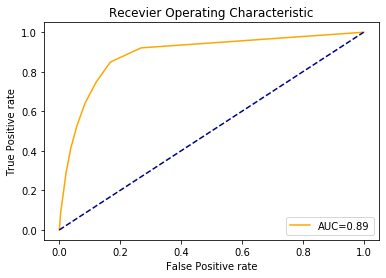

In [126]:
BC=BaggingClassifier()
BC.fit(X_train,Y_train)
Y_predict=BC.predict(X_test)
cm=confusion_matrix(Y_test,Y_predict)
print('BC Score=',BC.score(X_test,Y_test)*100)
print('\n')
print('confusion Matrix is:',cm,sep='\n')
print('\n')
from sklearn import metrics
probs=BC.predict_proba(X_test)
prob_positive =probs[:,1]
fpr,tpr,threshold=metrics.roc_curve(Y_test,prob_positive)
roc_auc=metrics.auc(fpr,tpr)
print('Area under the curve:',roc_auc)
print('\n')
plt.title('Recevier Operating Characteristic')
plt.plot(fpr,tpr,'orange',label='AUC=%0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.ylabel('True Positive rate')
plt.xlabel('False Positive rate')
plt.show()

# GradientBoostingClassifier

In [122]:
from sklearn.ensemble import GradientBoostingClassifier

GBC Score= 90.00331748313613


confusion Matrix is:
[[7726  254]
 [ 650  413]]


Area under the curve: 0.9165896868228898




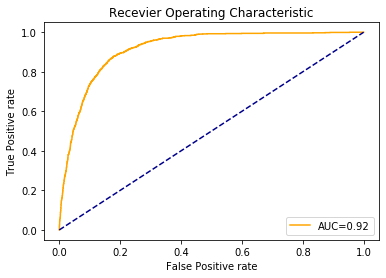

In [127]:
GBC=GradientBoostingClassifier()
GBC.fit(X_train,Y_train)
Y_predict=GBC.predict(X_test)
cm=confusion_matrix(Y_test,Y_predict)
print('GBC Score=',GBC.score(X_test,Y_test)*100)
print('\n')
print('confusion Matrix is:',cm,sep='\n')
print('\n')
from sklearn import metrics
probs=GBC.predict_proba(X_test)
prob_positive =probs[:,1]
fpr,tpr,threshold=metrics.roc_curve(Y_test,prob_positive)
roc_auc=metrics.auc(fpr,tpr)
print('Area under the curve:',roc_auc)
print('\n')
plt.title('Recevier Operating Characteristic')
plt.plot(fpr,tpr,'orange',label='AUC=%0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.ylabel('True Positive rate')
plt.xlabel('False Positive rate')
plt.show()

# RandomForestClassifier

In [124]:
from sklearn.ensemble import RandomForestClassifier

RFC Score= 90.14707508570164


confusion Matrix is:
[[7707  273]
 [ 618  445]]


Area under the curve: 0.9211883778118862




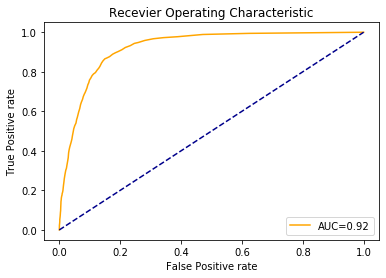

In [125]:
RFC=RandomForestClassifier()
RFC.fit(X_train,Y_train)
Y_predict=RFC.predict(X_test)
cm=confusion_matrix(Y_test,Y_predict)
print('RFC Score=',RFC.score(X_test,Y_test)*100)
print('\n')
print('confusion Matrix is:',cm,sep='\n')
print('\n')
from sklearn import metrics
probs=RFC.predict_proba(X_test)
prob_positive =probs[:,1]
fpr,tpr,threshold=metrics.roc_curve(Y_test,prob_positive)
roc_auc=metrics.auc(fpr,tpr)
print('Area under the curve:',roc_auc)
print('\n')
plt.title('Recevier Operating Characteristic')
plt.plot(fpr,tpr,'orange',label='AUC=%0.2f' % roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],color='darkblue',linestyle='--')
plt.ylabel('True Positive rate')
plt.xlabel('False Positive rate')
plt.show()

# 3. Make a DataFrame to compare models and their metrics. Give conclusion regarding the best algorithm and your reason behind it. 

In [132]:
models = {'model': ['LRR Score','DT Score','BC Score','GBC Score','RFC Score'],
         'score': [88.47,86.78,89.77,90.003,90.147]}

In [133]:
df = pd.DataFrame(models)

print (df)

       model   score
0  LRR Score  88.470
1   DT Score  86.780
2   BC Score  89.770
3  GBC Score  90.003
4  RFC Score  90.147


# The accuracy of RandomForestClassifier is 90.147 which is higher than the accuracy of Logistic Regression,DecisionTreeclassifier,BaggingClassifier,GradientBoostingClassifier. And we also prefer to choose the model which has high area under the curve and for RandomForestClassifier area under the curve is also high as compared to logistic andDecisionTree, hence RandomForestClassifier model is good.